### Automatic cycling route generator
adapted from the article](https://medium.com/p/16a266d468a5/edit) and from OSMmx documentation (espexialy the osmnx-examples/notebooks
/12-node-elevations-edge-grades.ipynb in (https://github.com/gboeing/osmnx-examples/tree/main/notebooks)


## Install all non built-in packages
#### ... and import them

In [11]:
!pip install pygeos
!pip install geopandas
#!pip install osmnx
# to get version 2.0.0
!pip install --pre osmnx 
!pip install folium
!pip install SRTM.py
!pip install matplotlib



In [2]:
import sys
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import osmnx as ox
import folium
import networkx as nx
import srtm
import time
import matplotlib.pyplot as plt
import collections
import multiprocessing as mp

# Choose the area to work with

## show it on Open Street Map

In [20]:
place_name = "Orsay, France"
G = ox.graph_from_place(place_name, network_type='drive')              # load a given graph and show it

# our_spot = (48.7, 2.18)                                                                                     # our spot ! (latitude between -90 et 90, longitude between -180 et 180)
# print(ox.geocode_to_gdf(f"{our_spot[0]}, {our_spot[1]}")) # Afficher les informations sur cet endroit
# sqr_dist = 3  # kms                                                                                                    # takes 4 minutes to download for 30 Kms square
# G = ox.graph_from_point(our_spot, dist=sqr_dist*1000, network_type='bike')   

# fig, ax = ox.plot_graph(G)
ox.graph_to_gdfs(G, nodes=False).explore()


# Test to be improved to show area of interest (tags) such as water, ..

See (https://wiki.openstreetmap.org/wiki/Tags)

In [6]:
# Define the tags for the features you are interested in
tags = {
    "drinking_water": "yes",
    "amenity": ["car_wash", "bicycle_repair_station"],
    "highway": ["cycleway", "path"],
}


# Initialize a dictionary to store the features
features = {}

# Try to fetch the features using the tags
try:
    features = ox.features_from_place(place_name, tags=tags)
    if features.empty:
        print("No data found for the specified tags and location.")
    else:
        # Proceed with further processing if data is found
        print("Data found, proceeding with further processing.")
except Exception as e:
    print(f"An error occurred: {e}")
    

# tiles = "cartodbdarkmatter"
tiles= "cartodbpositron"
# tiles="OpenStreetMap"

# Create a folium map centered around the graph
centroid = features.geometry.unary_union.centroid
m = folium.Map(location=[centroid.y, centroid.x], zoom_start=14, tiles=tiles)

# Define colors and icons for different types of features
feature_colors = {
    "drinking_water": "blue",
    "car_wash": "red",
    "bicycle_repair_station": "orange",
    "cycleway": "purple",
    "path": "brown"
}

feature_icons = {
    "drinking_water": "tint",
    "car_wash": "car",
    "bicycle_repair_station": "wrench",
    "path": "road"
}

# Add the features to the map with different colors and icons
for idx, row in features.iterrows():
    feature_type = row['amenity'] if 'amenity' in row else row['highway'] if 'highway' in row else None
    color = feature_colors.get(feature_type, "gray")
    icon = feature_icons.get(feature_type, "info-sign")

    if row.geometry.geom_type == "Point":
        folium.Marker(
            location=(row.geometry.y, row.geometry.x),
            icon=folium.Icon(color=color, icon=icon, prefix='fa')
        ).add_to(m)
    elif row.geometry.geom_type == "LineString":
        folium.PolyLine(
            [(pt[1], pt[0]) for pt in row.geometry.coords],
            color=color,
            weight=2
        ).add_to(m)

# Display the map
m


Data found, proceeding with further processing.


# Calculate and Plot the attributes: speed, travel time, elevation, grade

In [21]:
import srtm

# Add edge speeds and travel times
G = ox.add_edge_speeds(G)               # impute speed on all edges missing data
G = ox.add_edge_travel_times(G)         # calculate travel time (seconds) for all edges

# Add elevation data using Google API if available, otherwise use SRTM
try:
    from keys import google_elevation_api_key
    G = ox.elevation.add_node_elevations_google(G, api_key=google_elevation_api_key)
    print("Elevation data added using Google Elevation API.")
except ImportError:
    print("Google Elevation API key not available. Using less accurate SRTM for elevation data.")
    
    # Instantiate the SRTM data object
    elevation_data = srtm.get_data()

    # Function to add elevation data to graph nodes
    def add_node_elevations_srtm(G, elevation_data):
        for node, data in G.nodes(data=True):
            elevation = elevation_data.get_elevation(data['y'], data['x'])
            if elevation is not None:
                G.nodes[node]['elevation'] = elevation
            else:
                G.nodes[node]['elevation'] = 0  # Set to 0 if elevation data is not available

    # Add elevation data to the graph nodes
    add_node_elevations_srtm(G, elevation_data)

# Calculate edge grades
G = ox.elevation.add_edge_grades(G)

nodes, edges = ox.graph_to_gdfs(G)    # Go with GeoPandas GeoDataFrames


Elevation data added using Google Elevation API.


# Plot the nodes by elevation
Plot them colored from low (violet) to high (yellow).

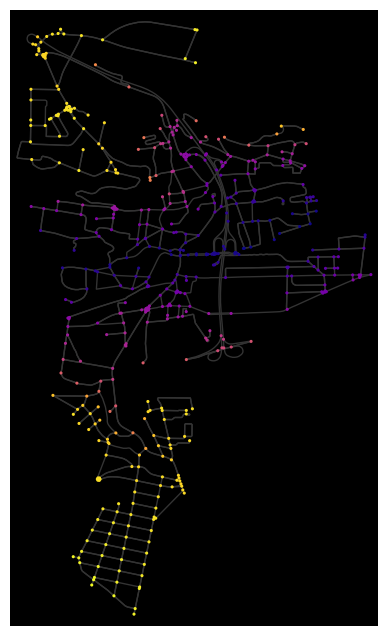

In [60]:
# get one color for each node, by elevation, then plot the network
nc = ox.plot.get_node_colors_by_attr(G, "elevation", cmap="plasma")
fig, ax = ox.plot_graph(G, node_color=nc, node_size=5, edge_color="#333333", bgcolor="k")

## 3D Plot the nodes by elevation
Plot them colored from low (violet) to high (yellow).

In [61]:
import plotly.graph_objs as go
import plotly.offline as py

# Extract node coordinates and elevations
node_x = [data['x'] for node, data in G.nodes(data=True)]
node_y = [data['y'] for node, data in G.nodes(data=True)]
node_z = [data['elevation'] for node, data in G.nodes(data=True)]

# Create a 3D scatter plot for nodes
node_trace = go.Scatter3d(
    x=node_x,
    y=node_y,
    z=node_z,
    mode='markers',
    marker=dict(
        size=4,
        color=node_z,  # Set color to elevation
        colorscale='Viridis',
        opacity=0.8,
        colorbar=dict(title='Elevation')
    ),
    name='Nodes'
)

# Create a 3D line plot for edges
edge_x = []
edge_y = []
edge_z = []

for u, v, data in G.edges(data=True):
    x0, y0, z0 = G.nodes[u]['x'], G.nodes[u]['y'], G.nodes[u]['elevation']
    x1, y1, z1 = G.nodes[v]['x'], G.nodes[v]['y'], G.nodes[v]['elevation']
    edge_x += [x0, x1, None]
    edge_y += [y0, y1, None]
    edge_z += [z0, z1, None]

edge_trace = go.Scatter3d(
    x=edge_x,
    y=edge_y,
    z=edge_z,
    mode='lines',
    line=dict(
        color='black',
        width=1
    ),
    name='Edges'
)

layout = go.Layout(
    title='3D Elevation Plot of Graph',
    scene=dict(
        xaxis_title='Longitude',
        yaxis_title='Latitude',
        zaxis_title='Elevation'
    ),
    showlegend=True
)

fig = go.Figure(data=[node_trace, edge_trace], layout=layout)
py.plot(fig, filename='3d_elevation_plot_with_edges.html')



'3d_elevation_plot_with_edges.html'

## Plot the edges by grade

Grade is the ratio of elevation change to edge length. Plot edges colored from low/flat (violet) to high/steep (yellow).

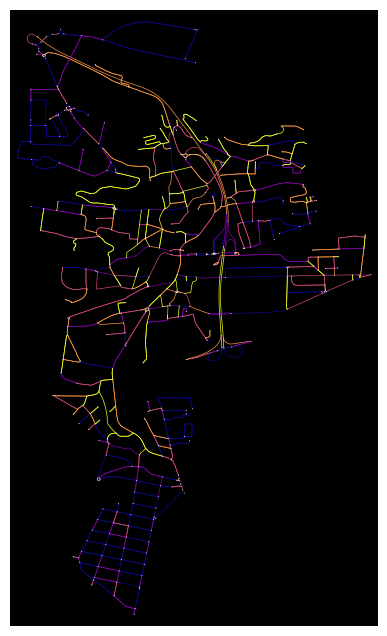

In [62]:
# get a color for each edge, by grade, then plot the network
ec = ox.plot.get_edge_colors_by_attr(G, "grade_abs", cmap="plasma", num_bins=5, equal_size=True)
fig, ax = ox.plot_graph(G, edge_color=ec, edge_linewidth=0.5, node_size=0.5, bgcolor="k")

# Calculate shortest paths, considering grade impedance

In [5]:
# select an origin and destination node (here the first and last) 
origin = list(G.nodes)[0]
destination = list(G.nodes)[-1]

In [6]:
# define some edge impedance function here


def impedance(length, grade):
    penalty = grade**2
    return length * penalty


# add impedance and elevation rise values to each edge in the projected graph
# use absolute value of grade in impedance function if you want to avoid uphill and downhill
for _, _, _, data in G.edges(keys=True, data=True):           # in the (u, v, key, data) interator u, v, and key are not needed (replaced by  _)
    data["impedance"] = impedance(data["length"], data["grade_abs"])
    data["rise"] = data["length"] * data["grade"]

#### First find the shortest path that minimizes *trip distance*:

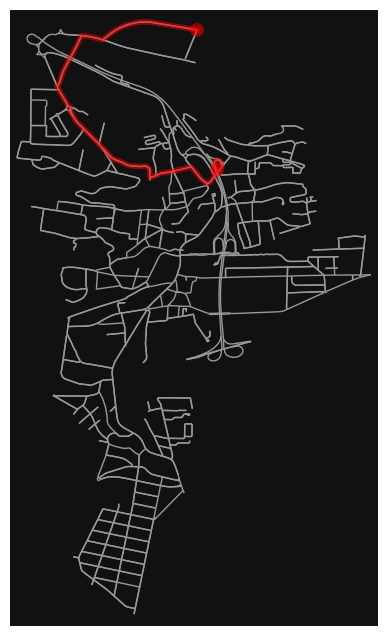

In [7]:
route_by_length = ox.shortest_path(G, origin, destination, weight="length")
fig, ax = ox.plot_graph_route(G, route_by_length, node_size=0)

#### Now find the shortest path that avoids slopes by minimizing *impedance* (function of length and grade):

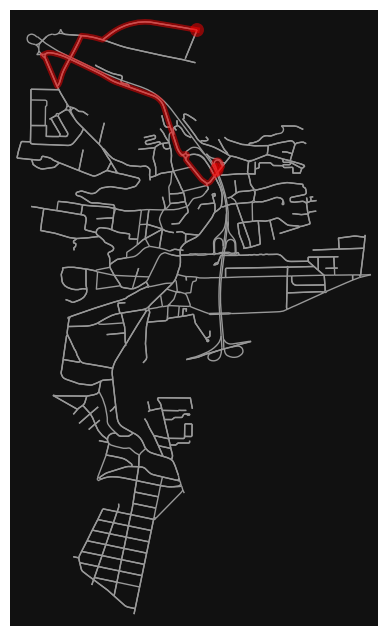

In [8]:
route_by_impedance = ox.shortest_path(G, origin, destination, weight="impedance")
fig, ax = ox.plot_graph_route(G, route_by_impedance, node_size=0)

#### Print some summary stats about these two routes:

In [9]:
def print_route_stats(route):
    route_grades = ox.routing.route_to_gdf(G, route, weight="grade_abs")["grade_abs"]
    msg = "The average grade is {:.1f}% and the max is {:.1f}%"
    print(msg.format(np.mean(route_grades) * 100, np.max(route_grades) * 100))

    route_rises = ox.routing.route_to_gdf(G, route, weight="rise")["rise"]
    ascent = np.sum([rise for rise in route_rises if rise >= 0])
    descent = np.sum([rise for rise in route_rises if rise < 0])
    msg = "Total elevation change is {:.1f} meters: {:.0f} meter ascent and {:.0f} meter descent"
    print(msg.format(np.sum(route_rises), ascent, abs(descent)))

    route_lengths = ox.routing.route_to_gdf(G, route, weight="length")["length"]
    print(f"Total trip distance: {np.sum(route_lengths):,.0f} meters")

In [10]:
# stats of route minimizing length
print_route_stats(route_by_length)

# stats of route minimizing impedance (function of length and grade)
print_route_stats(route_by_impedance)

The average grade is 4.4% and the max is 24.8%
Total elevation change is 81.8 meters: 92 meter ascent and 11 meter descent
Total trip distance: 3,282 meters
The average grade is 2.9% and the max is 6.2%
Total elevation change is 81.8 meters: 89 meter ascent and 8 meter descent
Total trip distance: 3,726 meters


# Make a list of all slopes

### Criteria for Defining a Climbing Road:


1. **Slope Threshold**:
   - **Setting a minimum slope threshold (e.g., 1%)**: Ensure the road is consistently uphill, avoiding flat or downhill segments.

2. **Boundary Conditions**:
   - **Starting Point**: The starting point should not be immediately adjacent to a lower (except is less than 1% slope) node, ensuring it is the beginning of the climb.
   - **Ending Point**: The ending point should not connect to a high (except is less than 1% slope)er node, indicating the top of the climb.

3. **Minimum Length**:
   - **Length Requirement**: Define a minimum length to ensure the climb is significant. This can be based o (100 m by default) and distance, elev (50 m by default)on of both.

4. **Path Selection**:
   - **Shortest Path**: Consider the first few shortest pa between same starting and ending pointsths (up to 5) to capture different possible routes that meet the criteria without being exhaustive.
   - **Road Type**: Differentiate between paved roads, trails, and other types of paths, as this might be relevant for specific BUt here not done applications.
ions.






In [38]:


# Function to Check if a Node is a Potential Starting Point for a Climb (that is no other node lower than this one within a decent slope consideration)
def is_potential_start_node(G, node, grade_threshold=0.01):
    for neighbor in G.neighbors(node):
        # Get the edge data
        edge_data = G.get_edge_data(node, neighbor)
        # Check the grade
        if edge_data[0].get('grade', 0) < -grade_threshold:
            return False
    return True

potential_start_nodes = [node for node in G.nodes if is_potential_start_node(G, node)]


def get_climbing_paths(G, start_node, min_grade=0.01)
    paths = [[start_node]]
    completed_paths = []

    while paths:
        current_path = paths.pop()
        last_node = current_path[-1]

        for neighbor in G.neighbors(last_node):
            edge_data = G.get_edge_data(last_node, neighbor)
            grade = edge_data[0].get('grade', 0)
            
            if grade >= min_grade and neighbor not in current_path:
                new_path = current_path + [neighbor]
                paths.append(new_path)

                if not any(G.nodes[neighbor]['elevation'] > G.nodes[next_node]['elevation'] for next_node in G.neighbors(neighbor) if next_node not in new_path):
                    completed_paths.append(new_path)
    return completed_paths

def filter_paths(G, paths, min_length=100, min_elevation_gain=50):
    valid_paths = []

    for path in paths:
        path_length = sum(ox.utils_graph.get_route_edge_attributes(G, path, 'length'))
        elevation_gain = G.nodes[path[-1]]['elevation'] - G.nodes[path[0]]['elevation']

        if path_length >= min_length and elevation_gain >= min_elevation_gain:
            valid_paths.append((path, path_length, elevation_gain))
    
    return valid_paths

valid_climbs = []

for start_node in potential_start_nodes:
    climbing_paths = get_climbing_paths(G, start_node)
    valid_climbing_paths = filter_paths(G, climbing_paths)

    valid_climbs.extend(valid_climbing_paths)

# Print valid climbs
for climb in valid_climbs:
    path, length, gain = climb
    print(f"Path: {path}, Length: {length} meters, Elevation Gain: {gain} meters")





# We are here now

In [14]:
def is_valid_slope(slope, threshold=0.01):
    return slope >= threshold

def calculate_path_length(path, edges):
    length = 0
    for u, v in zip(path[:-1], path[1:]):
        length += edges.loc[(edges['u'] == u) & (edges['v'] == v), 'length'].values[0]
    return length

def calculate_elevation_gain(path, edges):
    gain = 0
    for u, v in zip(path[:-1], path[1:]):
        slope = edges.loc[(edges['u'] == u) & (edges['v'] == v), 'grade'].values[0]
        length = edges.loc[(edges['u'] == u) & (edges['v'] == v), 'length'].values[0]
        gain += slope * length
    return gain

def is_climbing_path(path, edges, slope_threshold=0.01):
    for u, v in zip(path[:-1], path[1:]):
        slope = edges.loc[(edges['u'] == u) & (edges['v'] == v), 'grade'].values[0]
        if not is_valid_slope(slope, slope_threshold):
            return False
    return True
    
def find_climbing_paths(G, nodes, edges, slope_threshold=0.01, min_length=100, min_gain=20, max_paths=5):
    climbing_paths = []

    for start_node in nodes.index:
        for end_node in nodes.index:
            if start_node != end_node:
                # Find all simple paths (or use another algorithm like Dijkstra's for efficiency)
                paths = list(nx.all_simple_paths(G, source=start_node, target=end_node))
                valid_climbs = []

                for path in paths:
                    if is_climbing_path(path, edges, slope_threshold):
                        path_length = calculate_path_length(path, edges)
                        elevation_gain = calculate_elevation_gain(path, edges)
                        
                        if path_length >= min_length and elevation_gain >= min_gain:
                            valid_climbs.append((path, path_length, elevation_gain))

                # Sort valid climbs by length and select the top paths
                valid_climbs = sorted(valid_climbs, key=lambda x: x[1])[:max_paths]
                climbing_paths.extend(valid_climbs)

    return climbing_paths

climbing_paths = find_climbing_paths(G, nodes, edges, slope_threshold=0.01, min_length=100, min_gain=20, max_paths=5)

# Convert results to a DataFrame for easy inspection
climbing_paths_df = pd.DataFrame(climbing_paths, columns=['Path', 'Length', 'Elevation Gain'])

# Display the results
import ace_tools as tools; tools.display_dataframe_to_user(name="Climbing Paths", dataframe=climbing_paths_df)


KeyboardInterrupt: 

# OLD CODE FOR Memory

In [84]:


# Define a function to filter edges by slope
def filter_climbing_edges(edges, min_slope=0.01):
    return edges[edges['grade'] > min_slope]

# Filter edges to keep only those with a slope greater than 1%
climbing_edges = filter_climbing_edges(edges)

# Convert the filtered edges back to a graph
def create_graph_from_edges(nodes, edges):
    H = nx.DiGraph()
    for _, row in edges.iterrows():
        H.add_edge(row['u'], row['v'], **row.to_dict())
    for _, row in nodes.iterrows():
        H.add_node(row.name, **row.to_dict())
    return H

H = create_graph_from_edges(nodes, climbing_edges)

# Identify candidate start and end nodes based on elevation
candidate_start_nodes = nodes.sort_values(by='elevation').head(10).index
candidate_end_nodes = nodes.sort_values(by='elevation').tail(10).index

# Find climbing paths
climbing_paths = []
for start_node in candidate_start_nodes:
    for end_node in candidate_end_nodes:
        if start_node != end_node:
            try:
                path = nx.shortest_path(H, source=start_node, target=end_node, weight='length')
                if all(G.nodes[path[i]]['elevation'] < G.nodes[path[i+1]]['elevation'] for i in range(len(path)-1)):
                    climbing_paths.append(path)
            except nx.NetworkXNoPath:
                continue

# Sort the paths by length and select the top N shortest climbing paths
climbing_paths = sorted(climbing_paths, key=lambda p: nx.path_weight(G, p, weight='length'))[:5]

# Create a folium map centered around the graph
centroid = nodes.unary_union.centroid
m = folium.Map(location=[centroid.y, centroid.x], zoom_start=14, tiles="OpenStreetMap")

# Add edges to the map
for _, row in edges.iterrows():
    geometry = row['geometry']
    if isinstance(geometry, LineString):
        folium.PolyLine([(pt[1], pt[0]) for pt in geometry.coords], color='#333', weight=2).add_to(m)
    elif geometry.geom_type == 'MultiLineString':
        for linestring in geometry:
            folium.PolyLine([(pt[1], pt[0]) for pt in linestring.coords], color='#333', weight=2).add_to(m)

# Add nodes to the map with their colors
node_elevations = [G.nodes[node]['elevation'] for node in G.nodes]
norm = colors.Normalize(vmin=min(node_elevations), vmax=max(node_elevations))
cmap = cm.get_cmap('plasma')
nc = [colors.to_hex(cmap(norm(elev))) for elev in node_elevations]

for node, color in zip(nodes.index, nc):
    folium.CircleMarker(location=(nodes.loc[node].y, nodes.loc[node].x),
                        radius=5,
                        color=color,
                        fill=True,
                        fill_color=color).add_to(m)

# Add climbing paths to the map
for path in climbing_paths:
    route_coordinates = [(G.nodes[node]['y'], G.nodes[node]['x']) for node in path]
    folium.PolyLine(route_coordinates, color='red', weight=5).add_to(m)

# Save or display the map
m.save("climbing_routes_map.html")
m


KeyError: 'u'